In [1]:
import Pkg
Pkg.activate(".")

using NMRflux
using DataFrames
using Plots
using SparseArrays

  Activating project at `~/Dropbox/Source/NMRflux.jl/demo`
[ Info: Precompiling NMRflux [d25eb878-a83b-4e0c-a1bb-544741aeade2] (cache misses: include_dependency fsize change (6), wrong source (2), mismatched flags (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
mlist=[
    "Glucose",
    "Lactic acid",
    "Alanine",
    "Leucine",
    "Valine",
    "Serine",
    "Isoleucine",
    "Pyruvic acid",
    "Citrate",
    "Phenylalanine",
    "Tyrosine",
    "Tryptophan",
    "Butyric acid",
    "Valeric acid",
    "Acetic acid",
    "Succinic acid",
    "glutaric acid",
    "ketoglutaric acid",
    "malic acid",
    "fumaric acid",
    "isocitric acid"
]

df=DataFrame("name"=>[],"id"=>[])
for M in mlist
    J=GISSMO.search(M)[1]
    push!(df,[J["name"],J["id"]])
end
df

Row,name,id
,Any,Any
1,(+/-)-Glucose,bmse000015
2,L-lactic-acid,bmse000208
3,L-alanine,bmse000028
4,L-leucine,bmse000042
5,L-valine,bmse000052
6,L-serine,bmse000048
7,L-Isoleucine,bmse000866
8,Pyruvic-acid,bmse000112
9,Citrate,bmse000076


In [3]:
using LinearAlgebra

function gfid(id,t)
    n,H=GISSMO.Hamiltonian(id)
    rho0=sum(SpinSim.SpinOp(n,SpinSim.Sx,k) for k=1:n)
    Fp=sum(SpinSim.SpinOp(n,SpinSim.Sp,k) for k=1:n)
    freqs,ints=SpinSim.Spectrum(rho0,Hermitian(H),Fp,nev=400)
    S = sum(i*exp.(-im*t*f) for (f,i) in zip(freqs,ints))
    return SpectData(S,(t,))
end

function gfidT(id,t)
    n,H=GISSMO.Hamiltonian(id)
    rho0=sum(SpinSim.SpinOp(n,SpinSim.Sx,k) for k=1:n)
    Fp=sum(SpinSim.SpinOp(n,SpinSim.Sp,k) for k=1:n)
    δt = step(t)
    P=SpinSim.expm(-im*δt*(H))
    fid = ComplexF64[]
    sizehint!(fid,length(t))
    ρ = rho0
    for (k,tk) in enumerate(t) 
        push!(fid, tr(ρ*Fp))
        ρ = P'*ρ*P
        droptol!(ρ,10*eps(Float64))
    end
    return SpectData(fid,(t,))
end

gfidT (generic function with 1 method)

In [4]:
step(1:0.1:100)

0.1

In [5]:
gfidT("bmse000025",0:5.0e-5:0.5)

10001-element SpectData{ComplexF64, 1} with coords:(0.0:5.0e-5:0.5,):
                16.0 + 0.0im
  14.941773091105762 - 5.409595833781209im
  11.945478152888509 - 9.98112609320589im
    7.51411000708685 - 13.023797082453987im
  2.3847507765803844 - 14.114381580948693im
  -2.603538823578811 - 13.168608375581467im
  -6.658998398711164 - 10.450859709955504im
   -9.17615083032977 - 6.520888717233108im
  -9.839127173002275 - 2.1279503332760057im
  -8.670807718576429 + 1.9276001088402293im
  -6.019504911224164 + 4.939356446331562im
  -2.486622061729374 + 6.4197494126262695im
  1.1903359530071138 + 6.182076202065564im
                     ⋮
  2.5944294208760947 + 0.9121818942628048im
  2.2321482620157322 - 0.05741653203067962im
  1.5309285437766853 - 0.6979132065332019im
   0.678011075481637 - 0.9029873338494513im
 -0.1129583068762533 - 0.6593069326215388im
 -0.6448611018629591 - 0.048788227790242555im
 -0.7769092000518819 + 0.767906628930557im
  -0.453528169375101 + 1.5835199852368889im
 0

In [6]:
process=Chain(
    ZeroFill([2<<15]),
    Apodize([3.5π]),
    FourierTransform([2<<15],[1])
)

FourierTransform(Integer[1], Integer[65536], true, FFTW forward plan for 65536-element array of ComplexF64
(dft-ct-dit/32
  (dftw-direct-32/8 "t3fv_32_neon")
  (dft-vrank>=1-x32/1
    (dft-ct-dit/32
      (dftw-direct-32/8 "t3fv_32_neon")
      (dft-direct-64-x32 "n2fv_64_neon"))))) ∘ Apodize(Union{Colon, Real}[10.995574287564276]) ∘ ZeroFill(Union{Colon, Integer}[65536])

  5.342672 seconds (18.49 M allocations: 2.008 GiB, 6.94% gc time, 1 lock conflict, 50.38% compilation time)
 25.467456 seconds (532.06 k allocations: 106.489 GiB, 11.49% gc time, 1 lock conflict)


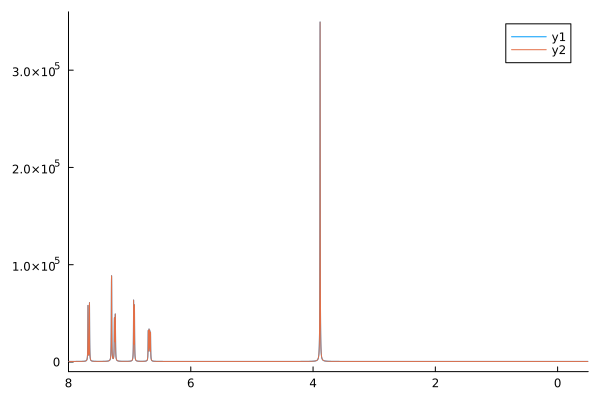

In [7]:
@time s = gfid("bmse000422",0:10.0e-5:1.0) |> process
@time st = gfidT("bmse000422",0:10.0e-5:1.0) |> process

plot(NMRflux.coords(s,1)/600 .+ 4.8,
    real(s),
    xaxis=:flip,
    yaxis=true,
    grid=false,
    xlims=[-0.5,8]
    )

plot!(NMRflux.coords(s,1)/600 .+ 4.8,real(st))

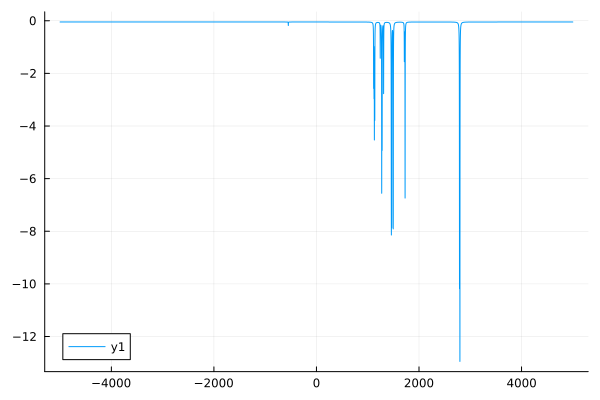

In [8]:
plot(NMRflux.coords(s,1),real(s-st))

In [9]:
Blist=[gfid(id,0:10.0e-5:1.0) |> process for id in df[!,"id"]]

21-element Vector{SpectData{ComplexF64, 1}}:
 [249.29511127506447 + 36.221982841861745im, 249.295141015791 + 36.23452346124702im, 249.29530757837352 + 36.24696429671474im, 249.29547093416207 + 36.25923589879483im, 249.29549379475384 + 36.27141297529124im, 249.29535843198948 + 36.283650810375434im, 249.29518175369486 + 36.29605312535159im, 249.29511581501762 + 36.30858382513338im, 249.2952184302851 + 36.32109772292608im, 249.29540398552427 + 36.333464089839595im  …  249.29545542514296 + 36.09856016891871im, 249.29545951971153 + 36.11073370021737im, 249.29531233369852 + 36.122983880405855im, 249.29514082695482 + 36.13540198686633im, 249.2950926448033 + 36.147936548301345im, 249.29521048339615 + 36.16043715343372im, 249.2953957672861 + 36.172782445397814im, 249.2954925393955 + 36.18498338341331im, 249.29542017108886 + 36.19717390718117im, 249.29524196407897 + 36.20949695657035im]
 [8.005644615303563 + 4.886387791340789im, 8.005636045618669 + 4.8867992130040445im, 8.005513113834922 + 4.887